<a href="https://colab.research.google.com/github/ngoanlc25ai/AdvanceDataScience/blob/main/Lung_Cance_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# About The Project

This project focuses on lung cancer detection using CT scan images from the **IQ-OTH/NCCD Lung Cancer Dataset**, collected by *The Iraq Oncology Teaching Hospital / National Center for Cancer Diseases*. The dataset includes three classes: **Normal**, **Benign**, and **Malignant**.

A **ResNet-18** model pretrained on **ImageNet** was used through **transfer learning**. The final fully connected layer was replaced to match the three output classes, and **all layers were fine-tuned** to adapt the model to medical imaging data. The model was trained using `CrossEntropyLoss`, the `AdamW` optimizer, and a `ReduceLROnPlateau` learning rate scheduler.

Performance was evaluated using `test loss`, `accuracy`, `classification report`, and `a confusion matrix`. The fine-tuned ResNet-18 achieved strong classification performance, demonstrating the effectiveness of transfer learning for automated lung cancer detection.

# Imports
Importing all necessary libraries for this project

In [1]:
import os
import random
from pathlib import Path
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from torchvision.models import resnet18, ResNet18_Weights

# Configs
Setting some important configurations and hyperparameters which is to be used in the project

In [2]:
DATA_DIR = '/kaggle/input/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset'
OUT_DIR = 'model'

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 5
LR = 1e-4
WEIGHT_DECAY = 1e-5
SEED = 42
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

os.makedirs(OUT_DIR, exist_ok=True)
print(f'Using device: {DEVICE}')

Using device: cpu


# Seed
Setting seed so that the model produces same result on every run

In [3]:
def setSeed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

setSeed(SEED)

# Class & Image Count

In [6]:
import kagglehub
from pathlib import Path

# Download latest version
path = kagglehub.dataset_download("adityamahimkar/iqothnccd-lung-cancer-dataset")
print("Path to dataset files:", path)

# Use the returned path instead of a hardcoded one
DATA_DIR = path  # ← this is the fix

def findImagePaths(data_dir, exts=('.png', '.jpg', '.jpeg')):
    data_dir = Path(data_dir)
    classes = []
    samples = []
    for cls_dir in sorted([d for d in data_dir.iterdir() if d.is_dir()]):
        cls_name = cls_dir.name
        classes.append(cls_name)
        for p in cls_dir.rglob('*'):
            if p.suffix.lower() in exts:
                samples.append((str(p), cls_name))
    return samples, classes

samples, classes = findImagePaths(DATA_DIR)
print(f'Classes: {classes}')
print(f'Total images: {len(samples)}')

Using Colab cache for faster access to the 'iqothnccd-lung-cancer-dataset' dataset.
Path to dataset files: /kaggle/input/iqothnccd-lung-cancer-dataset
Classes: ['Test cases', 'The IQ-OTHNCCD lung cancer dataset']
Total images: 1294


# Class Distribution

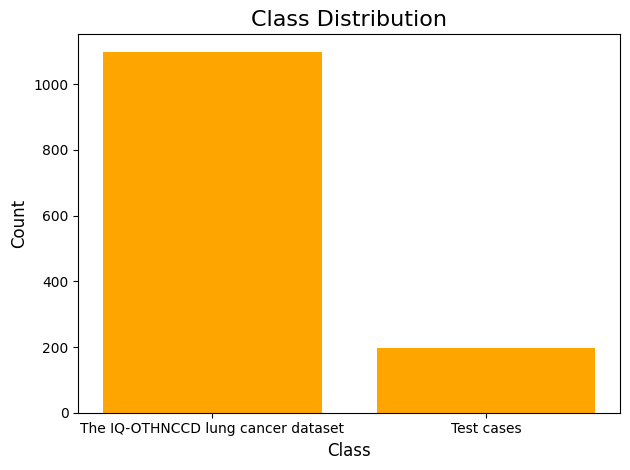

The IQ-OTHNCCD lung cancer dataset: 1097
Test cases: 197


In [7]:
labels = [s[1] for s in samples]
counts = Counter(labels)

counts = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True))

classes = list(counts.keys())
values = list(counts.values())

bars = plt.bar(classes, values, color='orange')

plt.title('Class Distribution', fontsize=16)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

for cls, count in counts.items():
    print(f'{cls}: {count}')

# Sample Dataset Images
Plotting 4 images per class

0 The IQ-OTHNCCD lung cancer dataset
1 Test cases


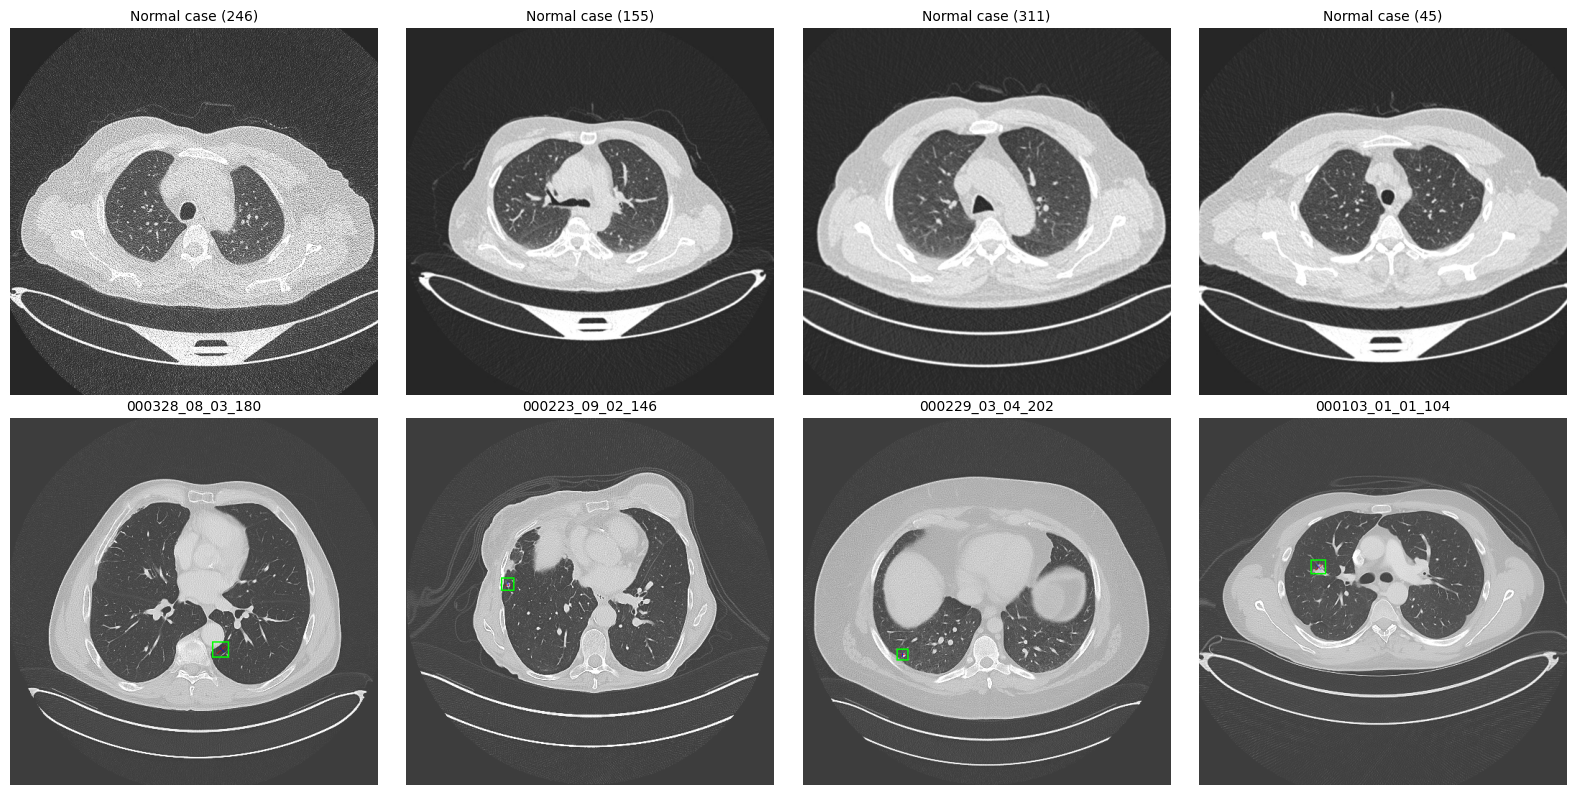

In [8]:
n_per_class = 4
fig, axes = plt.subplots(len(classes), n_per_class, figsize=(n_per_class*4, len(classes)*4))

for i, cls in enumerate(classes):
    print(i, cls)
    cls_imgs = [s[0] for s in samples if s[1] == cls][:n_per_class]
    for j, path in enumerate(cls_imgs):
        img = Image.open(path)
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        label = os.path.splitext(os.path.basename(path))[0]
        axes[i, j].set_title(label, fontsize=10, pad=5)
        if j == 0:
            axes[i, j].set_ylabel(cls, rotation=0, labelpad=30, fontsize=15, weight='bold')
plt.tight_layout()
plt.show()

# Dataset Class Declaration

In [10]:
class ScannedImageDataset(Dataset):
    def __init__(self, samples, class_to_idx, transform=None):
        self.samples = samples
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, cls = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = self.class_to_idx[cls]
        return img, label

# Split Data

In [11]:
class_to_idx = {c: i for i, c in enumerate(classes)}
paths = [s[0] for s in samples]
labels = [class_to_idx[s[1]] for s in samples]

trainval_idx, test_idx = train_test_split(
    np.arange(len(samples)), test_size=0.1, stratify=labels, random_state=SEED
)
train_idx, val_idx = train_test_split(
    trainval_idx, test_size=0.2, stratify=np.array(labels)[trainval_idx], random_state=SEED
)

train_samples = [samples[i] for i in train_idx]
val_samples = [samples[i] for i in val_idx]
test_samples = [samples[i] for i in test_idx]

print(f'Train: {len(train_samples)}, Val: {len(val_samples)}, Test: {len(test_samples)}')

Train: 931, Val: 233, Test: 130


# Transformation & Data Loaders

Here the `mean` and `std` values are taken as per `ImageNet`

In [12]:
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

test_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

train_ds = ScannedImageDataset(train_samples, class_to_idx, transform=train_transform)
val_ds   = ScannedImageDataset(val_samples, class_to_idx, transform=test_transform)
test_ds  = ScannedImageDataset(test_samples, class_to_idx, transform=test_transform)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_dl  = DataLoader(test_ds, batch_size=BATCH_SIZE)

# ResNet-18
For transfer learning and using that to classify lung cancer images

In [13]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(classes))

model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 123MB/s]


In [14]:
def trainOneEpoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct = 0, 0
    for imgs, labels in tqdm(loader, desc='Train', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
    return running_loss / len(loader.dataset), correct / len(loader.dataset)


def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct = 0, 0
    preds_all, labels_all = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc='Eval', leave=True):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(1)
            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())
            correct += (preds == labels).sum().item()
    return running_loss / len(loader.dataset), correct / len(loader.dataset), \
    np.array(preds_all), np.array(labels_all)

# Training
Here the model is trained for just 5 epochs


Epoch 1/5


Eval: 100%|██████████| 8/8 [00:24<00:00,  3.08s/it]


Train Loss: 0.1289, Acc: 0.9388
Val   Loss: 0.0520, Acc: 0.9785
Model saved

Epoch 2/5


Eval: 100%|██████████| 8/8 [00:28<00:00,  3.53s/it]


Train Loss: 0.0063, Acc: 0.9989
Val   Loss: 0.0019, Acc: 1.0000
Model saved

Epoch 3/5


...

Train Loss: 0.0054, Acc: 0.9989
Val   Loss: 0.0021, Acc: 1.0000

Epoch 4/5


Eval: 100%|██████████| 8/8 [00:24<00:00,  3.06s/it]


Train Loss: 0.0250, Acc: 0.9914
Val   Loss: 0.0022, Acc: 1.0000

Epoch 5/5


Eval: 100%|██████████| 8/8 [00:24<00:00,  3.05s/it]


Train Loss: 0.0022, Acc: 1.0000
Val   Loss: 0.0009, Acc: 1.0000
Model saved


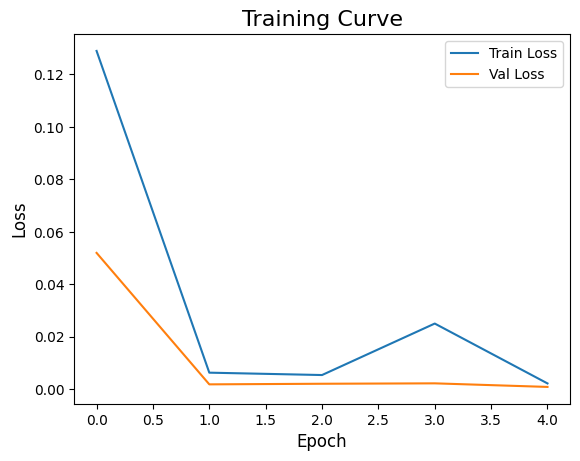

In [15]:
best_val_loss = np.inf
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    print(f'\nEpoch {epoch+1}/{EPOCHS}')
    train_loss, train_acc = trainOneEpoch(model, train_dl, criterion, optimizer)
    val_loss, val_acc, _, _ = evaluate(model, val_dl, criterion)

    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f'Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}')
    print(f'Val   Loss: {val_loss:.4f}, Acc: {val_acc:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), f'{OUT_DIR}/model_weights.pth')
        torch.save(model, f'{OUT_DIR}/model.pt')
        print('Model saved')

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title('Training Curve', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.show()

# Evaluate

Eval: 100%|██████████| 5/5 [00:13<00:00,  2.76s/it]

Test Loss: 0.0009, Test Acc: 1.0000

Classification Report:
                                    precision    recall  f1-score   support

The IQ-OTHNCCD lung cancer dataset       1.00      1.00      1.00       110
                        Test cases       1.00      1.00      1.00        20

                          accuracy                           1.00       130
                         macro avg       1.00      1.00      1.00       130
                      weighted avg       1.00      1.00      1.00       130



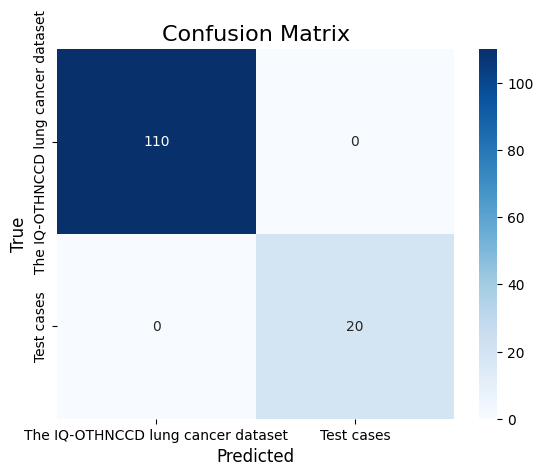

In [16]:
model.load_state_dict(torch.load(f'{OUT_DIR}/model_weights.pth'))
test_loss, test_acc, preds, labels = evaluate(model, test_dl, criterion)
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

print('\nClassification Report:')
print(classification_report(labels, preds, target_names=classes))

cm = confusion_matrix(labels, preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Confusion Matrix', fontsize=16)
plt.show()

In [18]:
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hooks = []

        def save_gradient(module, grad_input, grad_output):
            self.gradients = grad_output[0]

        def save_activation(module, input, output):
            self.activations = output

        self.hooks.append(self.target_layer.register_forward_hook(save_activation))
        self.hooks.append(self.target_layer.register_backward_hook(save_gradient))

    def generate_heatmap(self, input_image, class_idx):
        self.model.zero_grad()
        output = self.model(input_image)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        loss = output[0, class_idx]
        loss.backward()

        # Global Average Pooling gradients
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)

        # (activations)
        heatmap = torch.sum(weights * self.activations, dim=1).squeeze()

        # ReLU
        heatmap = F.relu(heatmap)

        # Normalize heatmap
        heatmap /= torch.max(heatmap)
        return heatmap.detach().cpu().numpy(), class_idx

    def remove_hooks(self):
        for hook in self.hooks:
            hook.remove()

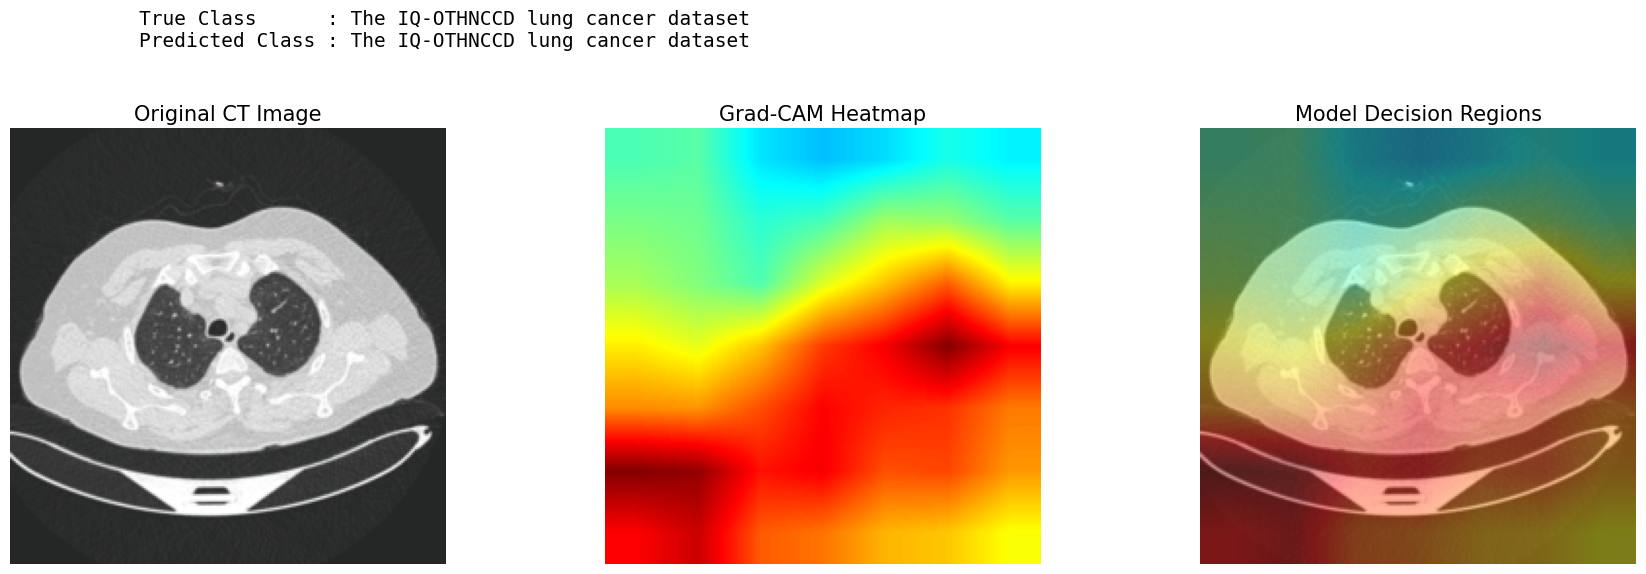

In [20]:
import cv2

def visualize_gradcam_result(model, dataset, idx, classes):
    # 1. Grad-CAM
    target_layer = model.layer4[-1]
    grad_cam = GradCAM(model, target_layer)

    # 2.
    img_tensor, label_idx = dataset[idx]
    input_tensor = img_tensor.unsqueeze(0).to(DEVICE)

    # 3.  Heatmap Prediction
    heatmap, pred_idx = grad_cam.generate_heatmap(input_tensor, class_idx=None)

    # 4.  (تحويلها لـ 0-255 و NumPy)
    inv_normalize = T.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    img_show = inv_normalize(img_tensor).permute(1, 2, 0).cpu().numpy()
    img_show = np.clip(img_show, 0, 1)
    img_uint8 = (img_show * 255).astype(np.uint8)

    # 5. Heatmap
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    # JET colormap
    heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    # 6. Heatmap (Decision Regions)
    #
    superimposed_img = cv2.addWeighted(img_uint8, 0.6, heatmap_color, 0.4, 0)

    # 7.
    plt.figure(figsize=(18, 6))

    # True و Predicted
    plt.suptitle(f"True Class      : {classes[label_idx]}\nPredicted Class : {classes[pred_idx]}",
                 fontsize=14, family='monospace', x=0.12, ha='left')

    # Original CT Image
    plt.subplot(1, 3, 1)
    plt.imshow(img_uint8)
    plt.title("Original CT Image", fontsize=15)
    plt.axis('off')

    # Grad-CAM Heatmap
    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_color)
    plt.title("Grad-CAM Heatmap", fontsize=15)
    plt.axis('off')

    # Model Decision Regions
    plt.subplot(1, 3, 3)
    plt.imshow(superimposed_img)
    plt.title("Model Decision Regions", fontsize=15)
    plt.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.9])
    plt.show()

    grad_cam.remove_hooks()

visualize_gradcam_result(model, test_ds, random.randint(0, len(test_ds)-1), classes)


--- Detailed Performance per Class ---
Class: The IQ-OTHNCCD lung cancer dataset
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

Class: Test cases
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000



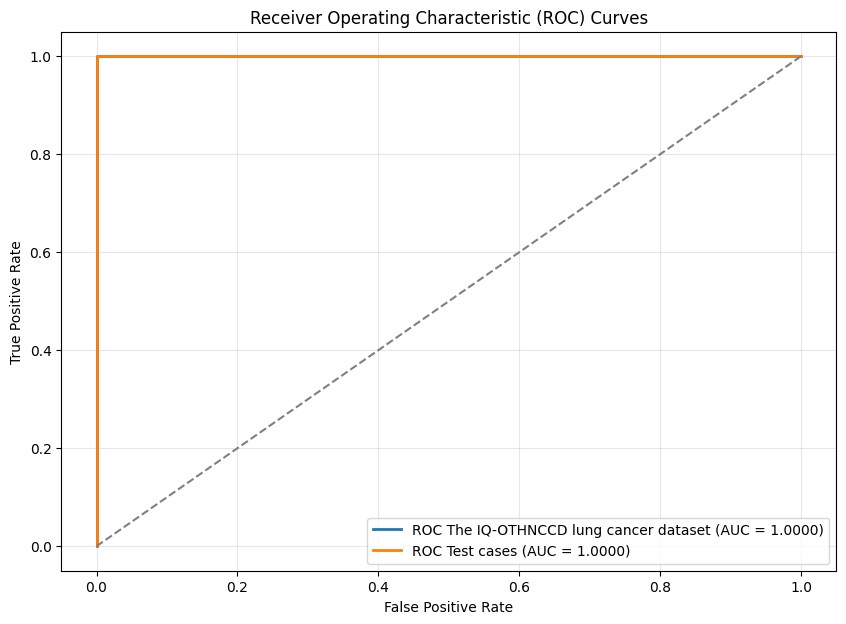

In [23]:
from sklearn.metrics import precision_recall_fscore_support, roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Per-class metrics
precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average=None)

print("\n--- Detailed Performance per Class ---")
for i, cls_name in enumerate(classes):
    print(f"Class: {cls_name}")
    print(f"  Precision: {precision[i]:.4f}")
    print(f"  Recall:    {recall[i]:.4f}")
    print(f"  F1-Score:  {f1[i]:.4f}\n")

# 2. Collect probabilities
model.eval()
all_probs = []
with torch.no_grad():
    for imgs, _ in test_dl:
        outputs = model(imgs.to(DEVICE))
        probs = torch.softmax(outputs, dim=1)
        all_probs.extend(probs.cpu().numpy())
all_probs = np.array(all_probs)

# 3. Binarize labels — fix for binary (2-class) edge case
y_test_bin = label_binarize(labels, classes=range(len(classes)))
if y_test_bin.shape[1] == 1:                          # binary case
    y_test_bin = np.hstack([1 - y_test_bin, y_test_bin])

# 4. ROC Curves
plt.figure(figsize=(10, 7))
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC {classes[i]} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [24]:
model.eval()
example_input = torch.rand(1, 3, 224, 224).to(DEVICE)
traced_script_module = torch.jit.trace(model, example_input)
traced_script_module.save("model_jit.pt")